# 5x Sit-to-Stand 

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

BASE = '../data/processed/'

def show_image(path, title=None, figsize=(13, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mpimg.imread(path))
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print('Ready.')

Ready.


## Keypoint Extraction Pipeline

- Ran **MediaPipe** and **MoveNet** in parallel to compare both models
- Analyzed confidence per joint and visualized on videos
- MediaPipe: stronger on upper body, MoveNet: stronger on lower body
- **Combine both**, MediaPipe as base, MoveNet fills where visibility < 0.6
- Remaining gaps rescued with **GPR** (Gaussian Process Regression)
- Result: **666 missing frames → 0**

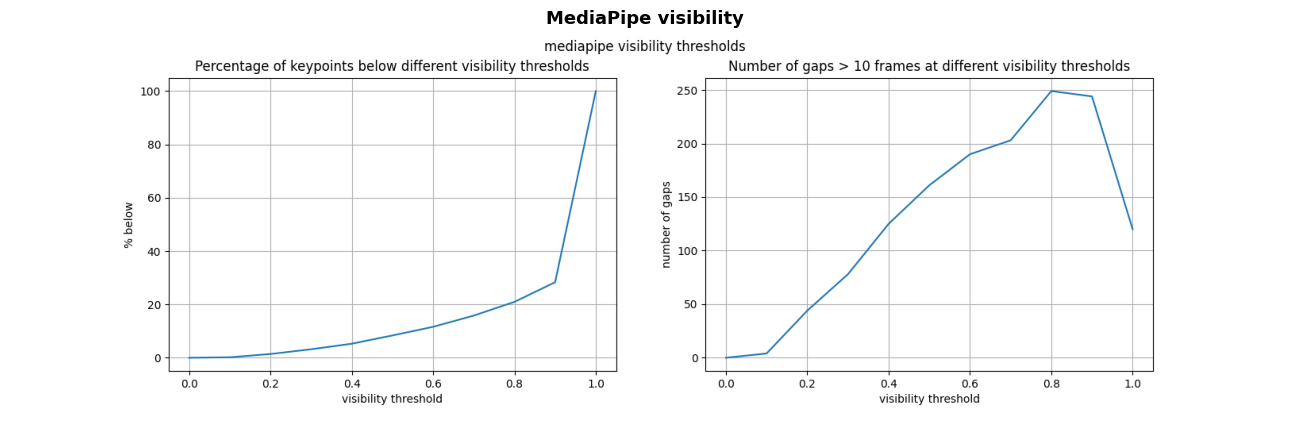

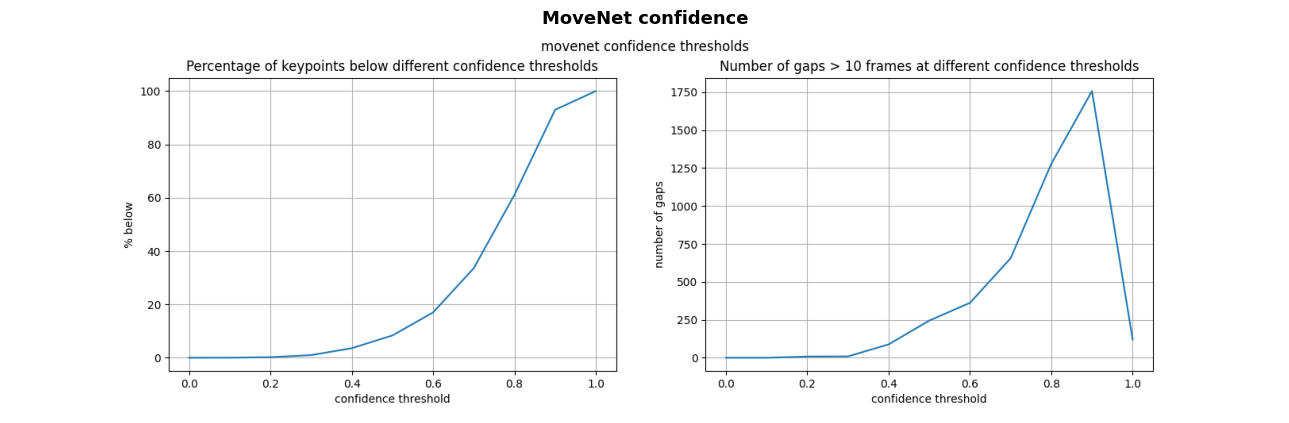

In [29]:
show_image(BASE + 'confidence_stats/mediapipe_threshold_plots.png','MediaPipe visibility')
show_image(BASE + 'confidence_stats/movenet_threshold_plots.png', 'MoveNet confidence')

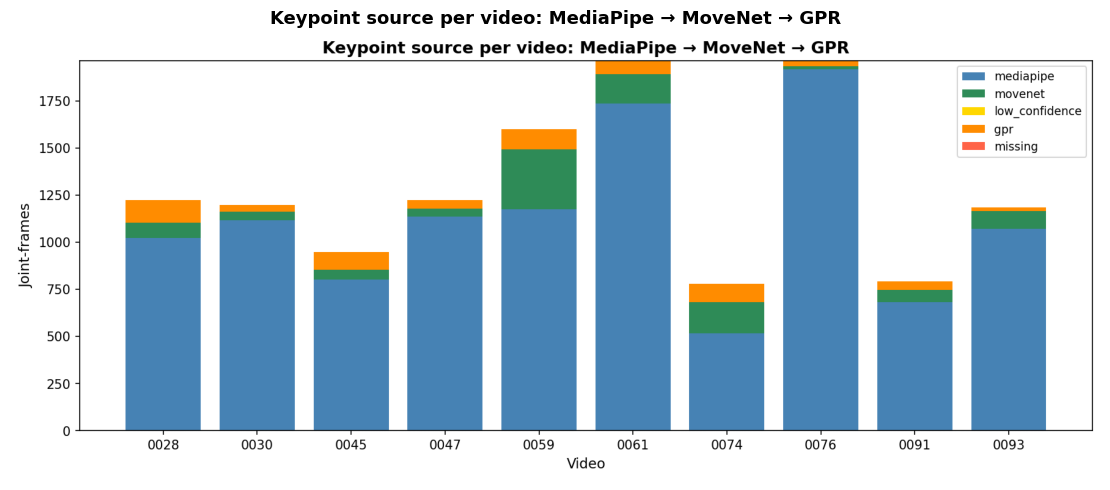

In [15]:
show_image(BASE + 'keypoint_source_distribution.png', 'Keypoint source per video: MediaPipe → MoveNet → GPR')

## MoLab Skeleton Animation

- MoLab uses 7 IMU sensors placed on body segments

## MoLab Sync 

## Feature Correlation with IRAF Scores

- Spearman correlation computed per phase (Utgångsposition, Rörelsestart, Rörelseutförande, Total)
- Both Pose and MoLab features compared against IRAF scores
- Top Pose feature: trunk angle (rho = 0.879)
- Top MoLab feature: pelvis tilt (rho = 0.842)

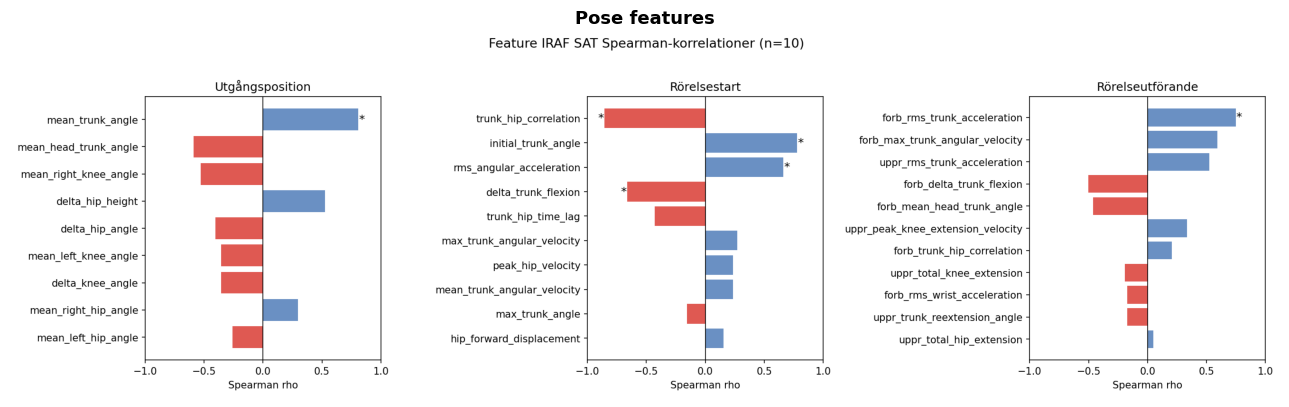

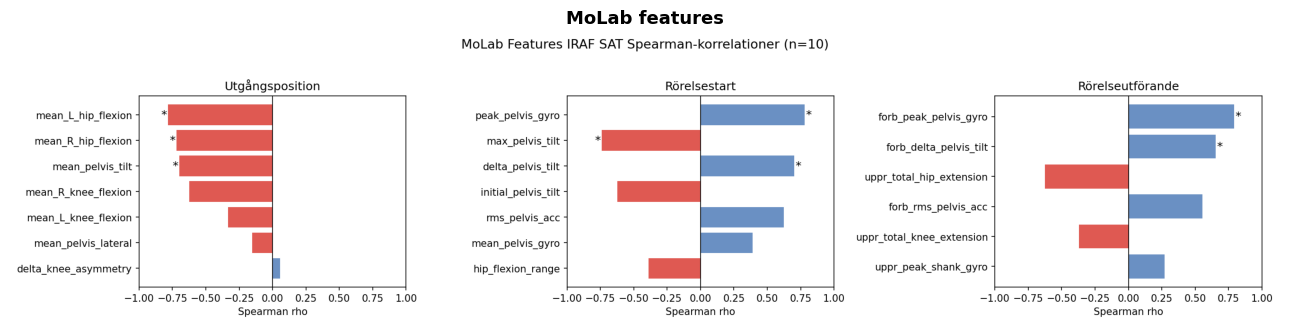

In [30]:
show_image( BASE + 'features/pose/per_video/correlation_heatmap.png',
    'Pose features')
show_image( BASE + 'features/molab/per_video/molab_correlation_heatmap.png',
    'MoLab features')

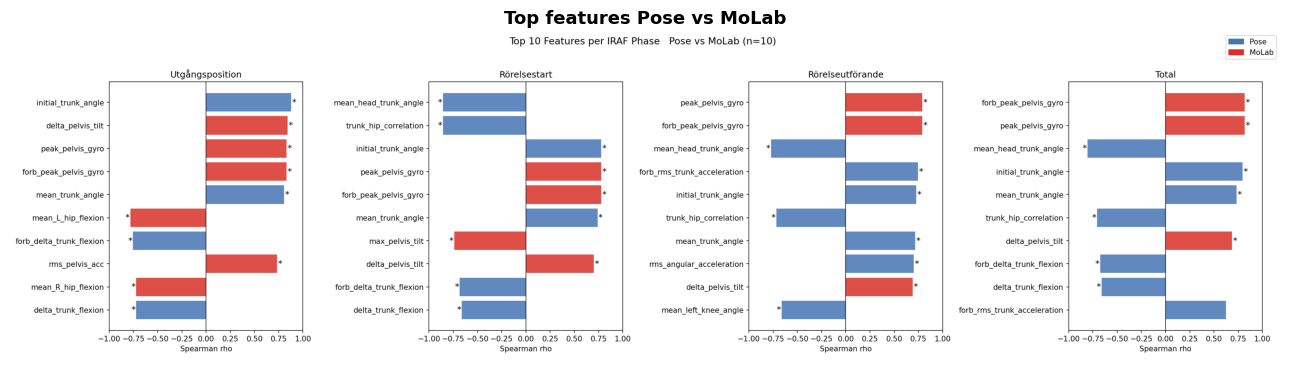

In [25]:
show_image(BASE + 'features/combined/per_video/combined_correlation_bar.png', 'Top features Pose vs MoLab')

## IRAF Scores - OMA Heatmaps

- IRAF scored per person, per phase, per arm condition

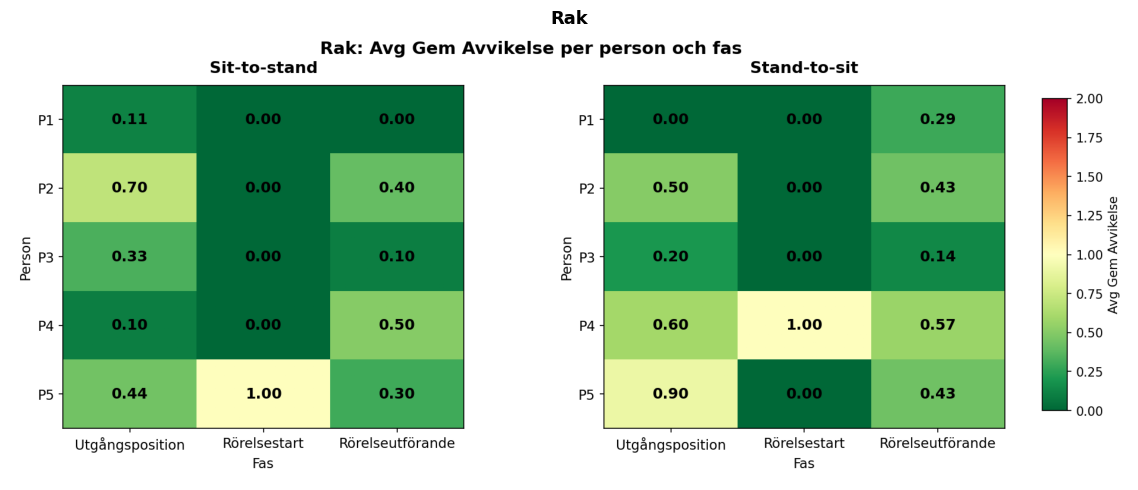

In [20]:
show_image(BASE + 'OMA_Score/heatmap_avvikelse_rak.png', 'Rak')

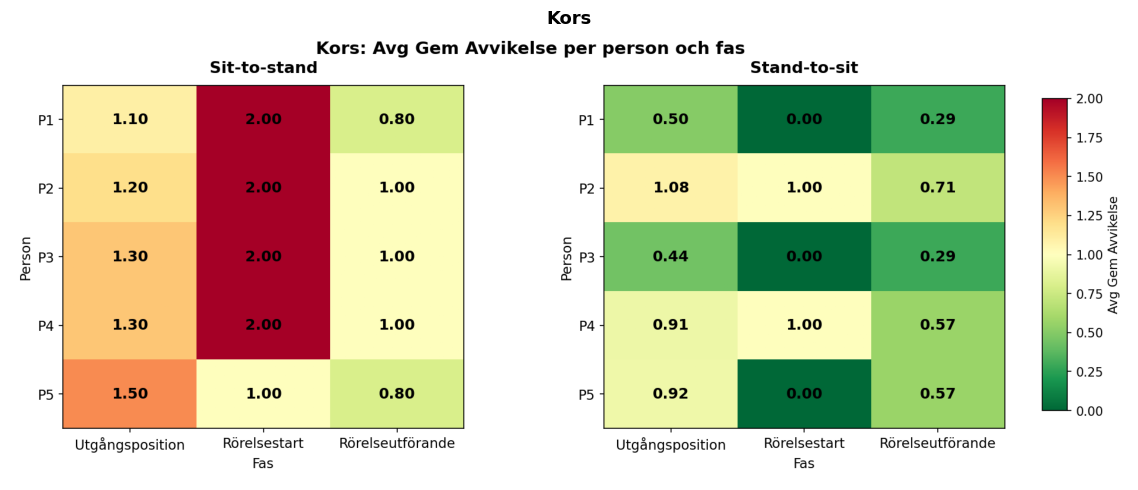

In [21]:
show_image(BASE + 'OMA_Score/heatmap_avvikelse_kors.png', 'Kors')

- Rak shows low deviation across all phases
- Kors sit-to-stand peaks at 2.00 in Rörelsestart, crossed arms occlude keypoints during peak acceleration
- Stand-to-sit performs better than sit-to-stand in the Kors condition

## Regression 

## Classification Pose vs MoLab

- Binary classification: high vs low IRAF score per phase
- Feature sets: Pose, MoLab, Combined
- Models: Logistic Regression, Random Forest, XGBoost
- Evaluated with leave-one-out cross-validation

In [23]:
champion = pd.read_csv(BASE + 'classification/champion_models.csv')
display(champion[['phase','feature_set','model','Accuracy','F1','AUC']].sort_values(['phase','feature_set']))

,phase,feature_set,model,Accuracy,F1,AUC
5,rörelsestart,combined,LogisticRegression,0.9,0.909,0.875
4,rörelsestart,molab,LogisticRegression,0.8,0.833,0.833
3,rörelsestart,pose,LogisticRegression,0.9,0.909,0.917
8,rörelseutförande,combined,LogisticRegression,1.0,1.000,1.000
7,rörelseutförande,molab,LogisticRegression,1.0,1.000,1.000
6,rörelseutförande,pose,LogisticRegression,1.0,1.000,1.000
11,total,combined,LogisticRegression,0.9,0.909,0.875
10,total,molab,LogisticRegression,0.7,0.769,0.833
9,total,pose,RandomForest,0.8,0.833,0.958
2,utgångsposition,combined,RandomForest,0.8,0.833,0.875


**Logistic Regression is the champion in 9 out of 12 combinations**.

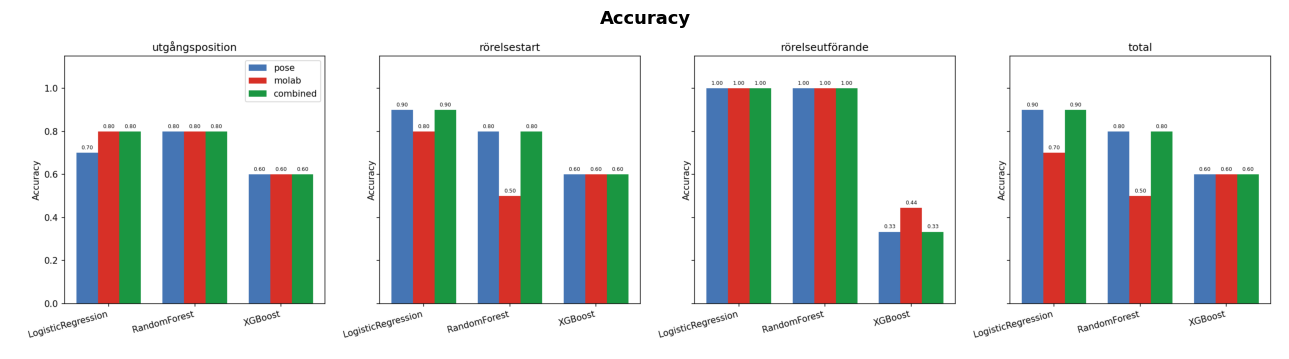

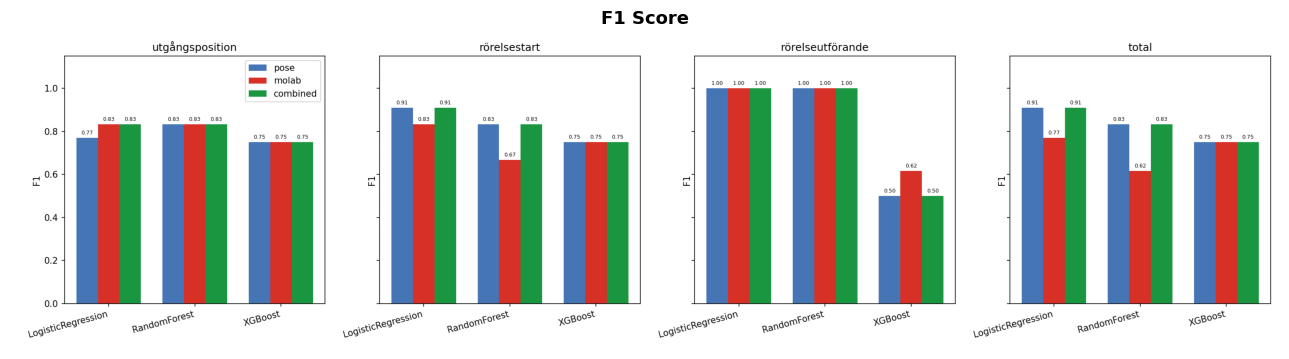

In [28]:
show_image(BASE + 'classification/classification_accuracy_bar.png', 'Accuracy')
show_image(BASE + 'classification/classification_f1_bar.png', 'F1 Score')

- Rörelseutförande: 100% accuracy across all feature sets
- Pose alone matches MoLab for most phases
- Combined features give best results for total IRAF prediction